### 1. Dependencies

In [1]:
import numpy as np
import pandas as pd
from itertools import chain
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


#functions
from functions.functions import low_high, set_first_row_to_zero
from functions.portfolio_strategy_design.univariate_sorting_preprocess import prepare_univariate_sorting_inputs
from functions.data_functions.get_data import get_row_universe, get_usa_universe, get_processed_fx_rates, get_snp_esg_merge_to_universe, get_refinitive_snp_merge_to_universe, get_famafrench_factors, get_processed_index
from functions.data_functions.process_data import process_row_universe, process_usa_universe, process_global_universe

In [2]:
# MANUAL INPUT
download_wrds_data = False#True
download_ff_data = False#True
esg_choice = "none"#refinitiv"#"s&p"#none" #refinitiv_n_s&p" 
start_year = 2013                 # these ESG sources are aligned for `start_year==2013`
end_year = 2024

#sector split
top_x_by_industry_even_split = 12

#Univariate Sorting
no_simple_quantiles = 6
# Thresholds
# default: alpha_bound = 0.05
alpha_bound = 0.1    # percentage of extremes to exclude from the GOLDEN data
mktcap_covered = 0.95 # target market cap coverage per currency area # Filters bottom 5% of market cap

Signal Design

In [3]:
#signal_type = "all_SDG_1D" # all_sdgs" # "people" # "people" #"planet"#"people"#"all_actions" # #

Filters

In [ ]:
region_analysis = "North_America"#"Europe_and_North_America"




execute_region_filters = False
drop_real_estate = True


if region_analysis == "Europe_and_North_America":
    #currencies we keep
    currency_filter = ['EUR', 'USD'] #['JPY'] #['CHF', 'GBP', 'EUR', 'USD'])]
    #region_filter = ["Europe", "United States and Canada"]
    fama_factor_region = "Developed"
    execute_region_filters = False


elif region_analysis == "North_America":
    currency_filter = ['USD'] #['JPY'] #['CHF', 'GBP', 'EUR', 'USD'])]
    
    region_filter = ["United States and Canada"]
    execute_region_filters = True #If this is false there is rediculouly high alpha as it includes Irland and swiss
    fama_factor_region = "North_America"







Signal Design

In [5]:
from functions.signal_design.signal_definitions import dict_all_SDG_1D, dict_2d_actions_stakeholders_original_matteo, test_multiple_signals

#Choose which action characterization to use
#categories_dict, signal_0_name, signal_1_name, signal_2_name = dict_all_SDG_1D()
categories_dict, signal_0_name, signal_1_name, signal_2_name = dict_2d_actions_stakeholders_original_matteo()
#categories_dict, signal_0_name, signal_1_name, signal_2_name, signal_3_name = test_multiple_signals()


In [6]:
# Signals merged from `lc` (computed from categories_dict in cell 20).
# Any column in `lc` can be added here; display name is the value.
lc_signals = {
    "signal_0": signal_0_name,
    "signal_1": signal_1_name,
    "signal_2": signal_2_name,
   
}

# Signals already present on `global_universe` (e.g. `esg` added in the WRDS section).
# Uncomment or add entries to include them in the univariate sorting pipeline.
universe_signals = {
    # "esg_sp": "esg_sp",
    # "esg_refinitive": "esg_refinitive",
}


In [7]:
analysis_selection = [("signal_2", "high")]#, ("esg_refinitive", "high")]# ("esg_sp", "high")]#, ("esg_refinitive", "high")]

if esg_choice == "none":
    analysis_selection = [("signal_2", "high")]
elif esg_choice == "refinitiv":
    analysis_selection = [("signal_2", "high"), ("esg_refinitive", "high")]
elif esg_choice == "s&p":
    analysis_selection = [("signal_2", "high"), ("esg_sp", "high")]
elif esg_choice == "refinitiv_n_s&p":
    analysis_selection = [("signal_2", "high"), ("esg_refinitive", "high"), ("esg_sp", "high")]


### 2. Data

Golden Data

In [8]:
#Golden Dataset Location
golden_location = "C:/Users/chris/Documents/GitHub/data/Golden_Data"


# Golden Dataset
#lc = pd.read_csv(f'{golden_location}/LC_dataset_v_2A.csv')
lc = pd.read_csv(f'{golden_location}/LC_dataset_v_2B1_20260409.csv')

# if signal_type != "all_actions":
#     # #3d counts
#     lc_3d  = pd.read_parquet(f"{golden_location}/LC_dataset_v_2A_3d_counts_gen2.parquet")
#     company_data = pd.read_parquet("./data/company_database_20260414.parquet")


#     #Preprocessing for merging
#     cols_to_merge = ['loc', 'MacroRegion', 'GICS_level_1', 'GICS_level_2', 'GICS_level_3', 'gvkey']
#     company_data = company_data.dropna(subset=["gvkey"])
#     lc_3d = lc_3d.dropna(subset=["gvkey"])
#     company_data["gvkey"] = company_data["gvkey"].astype("Int64").astype("string")
#     lc_3d['gvkey'] = lc_3d['gvkey'].astype(int).astype(str)



#     company_dim = company_data[cols_to_merge].drop_duplicates(subset=["gvkey"])
#     lc = lc_3d.merge(company_dim, on="gvkey", how="left", validate="m:1")




#### 2.1 LC dataset

In [9]:
from functions.data_functions.process_lc import process_lc, map_sectors, filter_sum_activities_by_fiscal_year_quantiles

lc = process_lc(lc, start_year, end_year)


if drop_real_estate:
    lc = lc[lc['GICS_level_1'] != 'Real Estate']

#print(lc['GICS_level_1'].unique())
lc['Industry'] = lc['GICS_level_1'].apply(map_sectors)

# # Filter to keep a stable panel meaning we have initiatives for all years
# gvkey_stable_panel = lc.groupby(['gvkey'])['gvkey'].count() == (lc['rfyear'].max()-lc['rfyear'].min()+1)
# gvkey_stable_panel = gvkey_stable_panel[gvkey_stable_panel].index
# lc = lc[lc['gvkey'].isin(gvkey_stable_panel)]


if execute_region_filters == True:
    lc = lc[lc["MacroRegion"].isin(region_filter)]


In [10]:
# from functions.signal_design.people_vs_planet import people_vs_planet
# categories_dict_people, categories_dict_planet, categories_dict_people_advocacy, categories_dict_planet_advocacy, categories_dict_prosperity, categories_dict_prosperity_advocacy, categories_dict_all_sdgs, categories_dict_all_sdgs_advocacy = people_vs_planet(categories_dict_actions)


# if signal_type == "all_SDG_1D":
#     categories_dict = dict_all_SDG_1D
# elif signal_type == "people":
#     categories_dict = categories_dict_people
# elif signal_type == "planet":
#     categories_dict = categories_dict_planet
# elif signal_type == "prosperity":
#     categories_dict = categories_dict_prosperity
# elif signal_type == "all_sdgs":
#     categories_dict = categories_dict_all_sdgs


1) Can use the total activites from all SDGS
2) Sub sample

In [11]:
for (key, value) in categories_dict.items():
    if f'sum_with_{value}' in lc.columns:
        lc[f'sum_with_{value}'] += lc[key]
    else:
        lc[f'sum_with_{value}'] = lc[key].values

lc['sum_activities'] = lc.loc[:, list(categories_dict.keys())].sum(axis=1)

In [12]:
lc["sum_activities"].describe()

count    15028.000000
mean        27.973915
std         32.631229
min          0.000000
25%          8.000000
50%         19.000000
75%         37.000000
max        699.000000
Name: sum_activities, dtype: float64

In [13]:
lc = filter_sum_activities_by_fiscal_year_quantiles(
    lc,
    lower_exclude= (alpha_bound/2),
    upper_exclude= (alpha_bound/2),
)

In [14]:
lc["sum_activities"].describe()

count    13225.000000
mean        24.618828
std         19.872985
min          3.000000
25%          9.000000
50%         19.000000
75%         35.000000
max        140.000000
Name: sum_activities, dtype: float64

Create the signal

In [15]:
max_category = max(categories_dict.values())
for i in range(max_category+1):
    lc[f'signal_{i}'] = lc[f'sum_with_{i}'] / lc['sum_activities']

Num stocks in USA and EU prior to some more filters

In [16]:
lc.loc[(lc['loc'] == 'USA') | (lc['MacroRegion'] == 'Europe'), 'gvkey'].nunique()

2807

#### 2.2 WRDS, Fama-French and FX data

Get and Process:
1- FX data

2- USA Universe

3- ROW Universe

4- Fama-French

5- Global Universe

In [17]:
# Download from FRB H.10
# https://www.federalreserve.gov/datadownload/Output.aspx?rel=H10&series=d3efeda92e22923be9b7c3d7250706ac&lastobs=&from=01/01/2009&to=12/31/2024&filetype=csv&label=include&layout=seriescolumn
fx_rates = get_processed_fx_rates(end_year)


usa_universe = get_usa_universe(start_year, end_year, download_wrds_data=False)
usa_universe = process_usa_universe(usa_universe)

row_universe = get_row_universe(start_year,end_year, download_wrds_data)
row_universe = process_row_universe(row_universe, fx_rates)

# This is a shortcut for the case without ESGs
if esg_choice == 'none':
    usa_universe['esg'] = 100
    row_universe['esg'] = 100

elif esg_choice != 'none':
    if esg_choice == 'refinitiv_n_s&p':
        usa_universe, row_universe = get_snp_esg_merge_to_universe(usa_universe, row_universe)
        usa_universe, row_universe = get_refinitive_snp_merge_to_universe(usa_universe, row_universe)
    elif esg_choice == "refinitiv":
        usa_universe, row_universe = get_refinitive_snp_merge_to_universe(usa_universe, row_universe)
    elif esg_choice == "s&p":
        usa_universe, row_universe = get_snp_esg_merge_to_universe(usa_universe, row_universe)    
  
fama_french= get_famafrench_factors(start_year, end_year, fama_factor_region,  download_developed_ff_data=False)



global_universe = process_global_universe(usa_universe, row_universe, currency_filter, mktcap_covered, esg_choice)

### 3. Univariate Portfolio sorting

In [ ]:
cols_standardization = ['rfyear', 'curcdd', 'Industry']



prep = prepare_univariate_sorting_inputs(
    global_universe=global_universe,
    lc=lc,
    fama_french=fama_french,
    lc_signals=lc_signals,
    universe_signals=universe_signals,
    category_columns=sorted(categories_dict.keys()),
    cols_standardization=cols_standardization,
    apply_geo_filter=False,
)

global_universe = prep.global_universe
global_returns  = prep.global_returns
signals         = prep.signals        # dict: column name -> (date x gvkey_iid) pivot
signal_names    = prep.signal_names   # dict: column name -> display name
signal_df       = prep.global_long_df
fama_french     = prep.fama_french




In [ ]:
# MANUAL SETTINGS (for UnivariateQuantilePortfolio in the next section)
first_conditioning_set = 0       # momentum-like strategies: increase to skip early rows
no_simple_extremes_quantiles = 1 # high and low portfolios
take_extremes = False            # if True, low / middle / high extremes only


#### 3.1 Univariate sorting

In [ ]:
from functions.portfolio_strategy_design.Univariate_Portfolio import UnivariateQuantilePortfolio

signal_quantiles: dict[str, pd.DataFrame] = {}
signal_quantile_constituents: dict[str, pd.Series] = {}

for col, pivot in signals.items():
    U = UnivariateQuantilePortfolio(
        signal=pivot,
        returns=global_returns,
        n_quantiles=no_simple_quantiles,
        first_conditioning_set=first_conditioning_set,
        take_extremes=take_extremes,
        n_extremes_quantiles=no_simple_extremes_quantiles,
    )
    signal_quantiles[col] = U.compute_returns()
    signal_quantile_constituents[col] = U.get_constituents_over_time()

# 4. Sector Split

Store constituents over time + compute “next-month return” by Industry

In [ ]:
from functions.portfolio_strategy_design.Sector_Portfolio import SectorPortfolio

# Sector portfolio is pinned to signal_2.
global_signal_2 = signals["signal_2"]

#Build an industry pivot aligned to global_returns  and global_signal_*
global_industry = global_universe.pivot(index="date", columns="gvkey_iid", values="Industry")

#This will automatically split the even_split_no stocks into the unique sectors.
#Select the n highest ranked stocks in each industruy and build portfolios using them.
S = SectorPortfolio(
    signal=global_signal_2,
    returns=global_returns,
    global_universe=global_universe,
    sector_split=top_x_by_industry_even_split,          # fixed N per industry
    manual_input_split=False,
    first_conditioning_set=first_conditioning_set,
    ascending=False,
)


#all_industry_returns = S.compute_industry_returns()
industry_constituents = S.get_constituents_over_time()   

#Below assumes that ALLLL INDUSTIES HAVE THE SAME NUMBER OF STOCKS!!!!!!!!
sector_portfolio_returns = S.equal_weight_mean_return() # equal-weight across industries


#### Return Preprocessing and adding MSCI

Add MSCI

In [ ]:
file_path = "./data/MSCI/MSCI_World.xlsx"
MSCI = get_processed_index(file_path, global_returns) 

Transform in excess returns using the risk free rate

In [ ]:
for col in signal_quantiles:
    signal_quantiles[col] = signal_quantiles[col].sub(fama_french['rf'].values, axis=0)

MSCI_excess_returns = MSCI["return"].sub(fama_french['rf'].values, axis=0)
sector_portfolio_returns = sector_portfolio_returns.sub(fama_french["rf"].values, axis=0)

Make sure the first row is 0, so they all start at the same date

In [ ]:
global_returns = set_first_row_to_zero(global_returns)
for col in signal_quantiles:
    signal_quantiles[col] = set_first_row_to_zero(signal_quantiles[col])
    
MSCI_excess_returns.iloc[0]      = 0
sector_portfolio_returns.iloc[0] = 0

# 5. Fama-French

In [ ]:
sector_portfolio_returns_df = pd.DataFrame()
sector_portfolio_returns_df[f"Sector equal split {signal_2_name}"] = sector_portfolio_returns
sector_portfolio_returns = sector_portfolio_returns_df

In [ ]:
from functions.fama_french import ff3_regressions

# FF3 table: every signal plus the sector portfolio.
ff3_parts = [
    low_high(
        ff3_regressions(signal_quantiles[col], fama_french.reset_index(drop=True)),
        signal_names[col],
    )
    for col in signal_quantiles
]
ff3_parts.append(ff3_regressions(sector_portfolio_returns, fama_french.reset_index(drop=True)))

ff3_parts_df = pd.concat(ff3_parts, axis=1).round(2)
#ff3_parts_df.to_csv('./output/ff3_' + _{start_date}-{end_date} + '.csv')
ff3_parts_df.head()

,Low advocacy,High advocacy,Low preparation,High preparation,Low transformation,High transformation,Sector equal split transformation
alpha,0.23,0.27,0.25,-0.01,0.23,0.38,0.19
beta_mkt,1.01,1.04,1.03,1.02,1.04,1.02,0.98
beta_smb,0.05,0.17,0.13,0.08,0.17,0.10,0.04
beta_hml,0.27,0.30,0.26,0.24,0.26,0.27,0.23
p-value(alpha),0.03,0.01,0.03,0.94,0.03,0.00,0.08


#### Rolling Alpha

In [ ]:
window_size = 40

from functions.fama_french import rolling_ff3_alphas

# Single selection shared with cumulative returns.
rolling_alpha_selection = analysis_selection

_valid_buckets = {"high", "low"}
_invalid_buckets = sorted({b for _, b in rolling_alpha_selection} - _valid_buckets)
if _invalid_buckets:
    raise ValueError(f"Invalid bucket(s) in analysis_selection: {_invalid_buckets}. Use 'high' or 'low'.")

_missing_signal_keys = sorted({c for c, _ in rolling_alpha_selection} - set(signal_quantiles))
if _missing_signal_keys:
    raise KeyError(f"Signal key(s) in analysis_selection not found in signal_quantiles: {_missing_signal_keys}")

_bucket_to_col    = {"high": f"p_{no_simple_quantiles}", "low": "p_1"}
_bucket_to_prefix = {"high": "High", "low": "Low"}

rolling_signals_arg = [
    {
        "label": f"{_bucket_to_prefix[bucket]} {signal_names[col]}",
        "returns": signal_quantiles[col],
        "alpha_column": _bucket_to_col[bucket],
    }
    for col, bucket in rolling_alpha_selection
]

_sector_label = f"Sector equal split {signal_2_name}"
rolling_signals_arg.append({
    "label": _sector_label,
    "returns": sector_portfolio_returns,
    "alpha_column": _sector_label,
})

rolling_alphas = rolling_ff3_alphas(
    signals=rolling_signals_arg,
    fama_french=fama_french,
    window_size=window_size,
)



# 6. Performance Metrics

In [ ]:
global_gross_portfolio_returns = pd.DataFrame(index=global_returns.index)
global_gross_portfolio_returns['Market'] = 1 + global_returns.mean(axis=1).sub(fama_french["rf"].values, axis=0)

# Single selection shared with rolling alpha.
portfolio_selection = analysis_selection

for col, bucket in portfolio_selection:
    quantile_col = _bucket_to_col[bucket]
    label        = f"{_bucket_to_prefix[bucket]} {signal_names[col]}"
    global_gross_portfolio_returns[label] = 1 + signal_quantiles[col][quantile_col]

_sector_col = f"Sector equal split {signal_2_name}"
global_gross_portfolio_returns[_sector_col] = 1 + sector_portfolio_returns[_sector_col]

#global_gross_portfolio_returns["MSCI benchmark"] = 1 + MSCI_excess_returns

portfolio_returns = global_gross_portfolio_returns - 1

# We only have ESG data till 2023

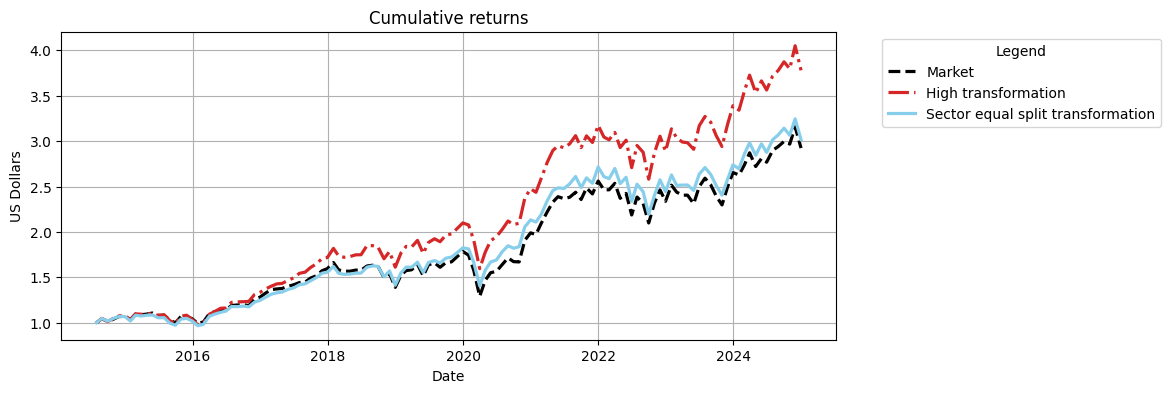

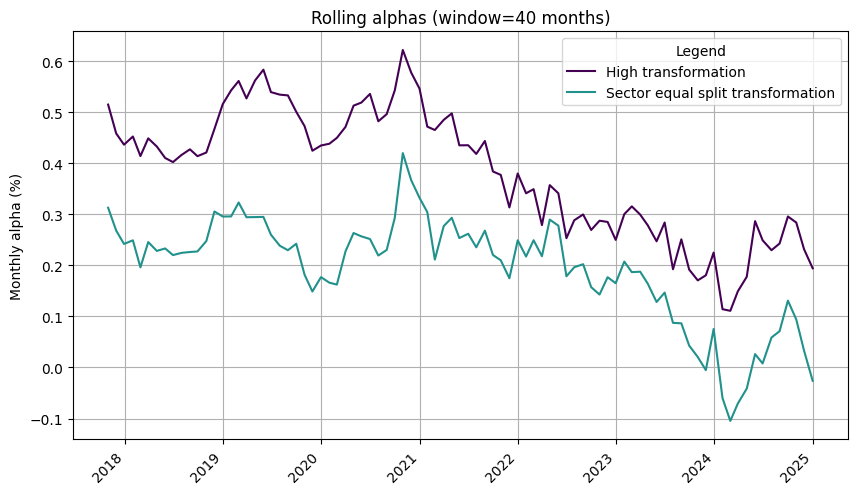

,1m,3m,YTD,1yr,3yr,5yr,10yr,Since launch
Market,-7.41%,-2.44%,10.16%,10.16%,14.18%,63.79%,173.00%,192.37%
High transformation,-6.69%,-2.42%,11.49%,11.49%,19.09%,80.03%,250.02%,278.03%
Sector equal split transformation,-7.04%,-4.01%,10.17%,10.17%,11.09%,65.31%,182.09%,201.69%


,Sharpe,VaR 1%,Max Drawdown,Alpha,p-value(alpha)
Market,0.69,-9.78%,-27.70%,,
High transformation,0.84,-10.24%,-23.99%,0.38,0.000
Sector equal split transformation,0.74,-10.20%,-22.93%,0.19,0.080


<Axes: title={'center': 'Rolling Annualised Sharpe (24-month window)'}, ylabel='Sharpe'>

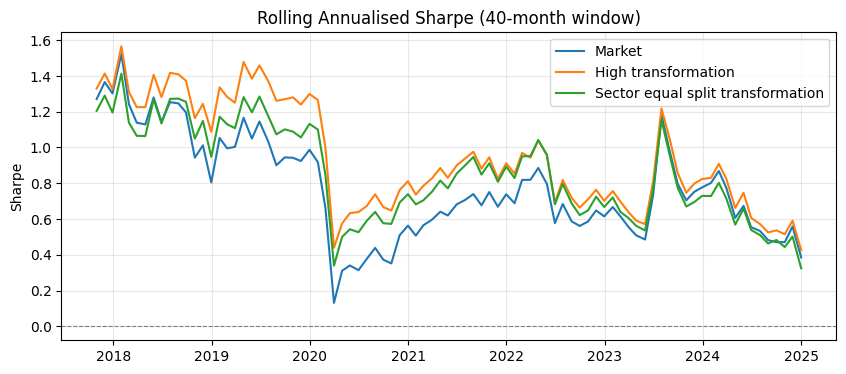

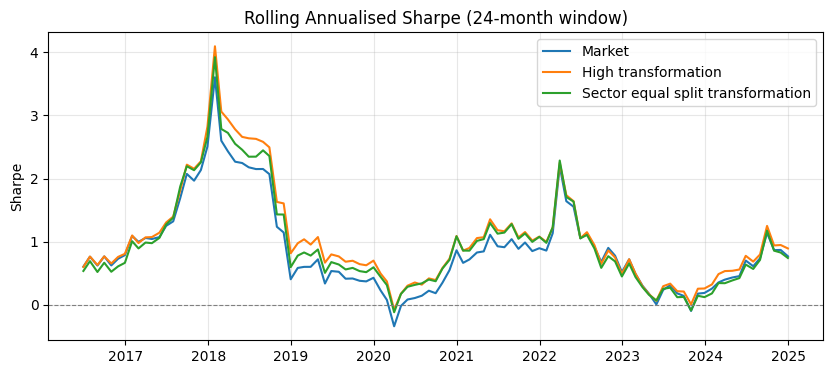

In [ ]:
from functions.Strategy_Perfomance import StrategyPerformance
from functions.fama_french import plot_rolling_alpha_function



start_date = str(portfolio_returns.index[0])[:7]
end_date = str(portfolio_returns.index[-1])[:7]

sp = StrategyPerformance(portfolio_returns, ff3_parts_df=ff3_parts_df)


cumulative_table = sp.cumulative_performance_table(
    csv_path=f"./output/strategy_cumulative_performance_{start_date}-{end_date}.csv")

risk_table = sp.performance_risk_metrics_table(
    csv_path=f"./output/strategy_performance_metrics_{start_date}-{end_date}.csv")



sp.plot_cumulative_returns(
    title="Cumulative returns",
    tight_layout_rect = (0, 5, 100, 0.9),
    save_path=f"./output/img/cumulative_returns_{start_date}-{end_date}.png"
)

# Note: sector-split alpha is appended later once `sector_portfolio_returns` exists.
plot_rolling_alpha_function(
    rolling_alphas,
    title="Rolling alphas (window=40 months)",
    save_path="./output/img/rolling_alphas_{start_date}-{end_date}.png",
)

display(cumulative_table)
display(risk_table)


sp.plot_rolling_sharpe(window=40, save_path=f"./output/img/strategy_rolling_sharpe_40m_{start_date}-{end_date}.png")
#sp.plot_rolling_sharpe(window=60, save_path=f"./output/img/strategy_rolling_sharpe_60m_{start_date}-{end_date}.png")
sp.plot_rolling_sharpe(window=24, save_path=f"./output/img/strategy_rolling_sharpe_24m_{start_date}-{end_date}.png")


# 7. Portfolio Constituents

### Portfolio constituents — category mix (`PortfolioConstituents`)

Uses `signal_2_simple_quantiles_constituents` and `global_universe` to inspect **Industry**, **`loc`**, and **MacroRegion**: line charts of stock counts over time (default = last quantile `p_k`, same as `constituents[i][-1]`) and donut charts for the **final** formation month. Optional: `analyse_all_portfolios_at_once=True` unions all `p_1`…`p_k`; `all_sub_portfolios=True` plots one subplot per quantile.


The following only inspects the high transformation

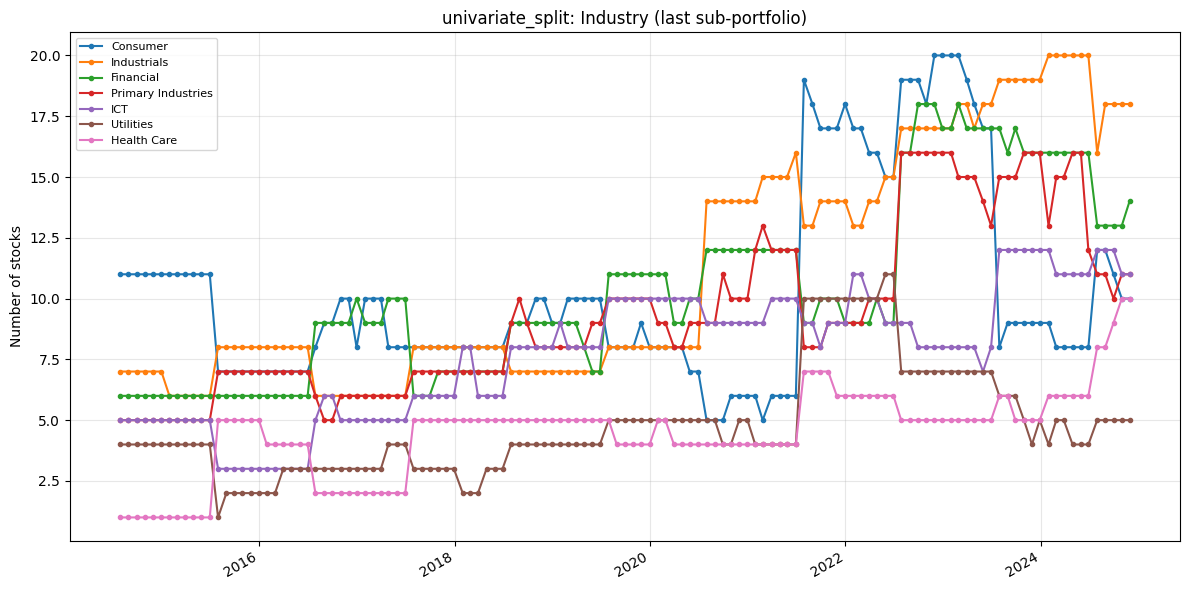

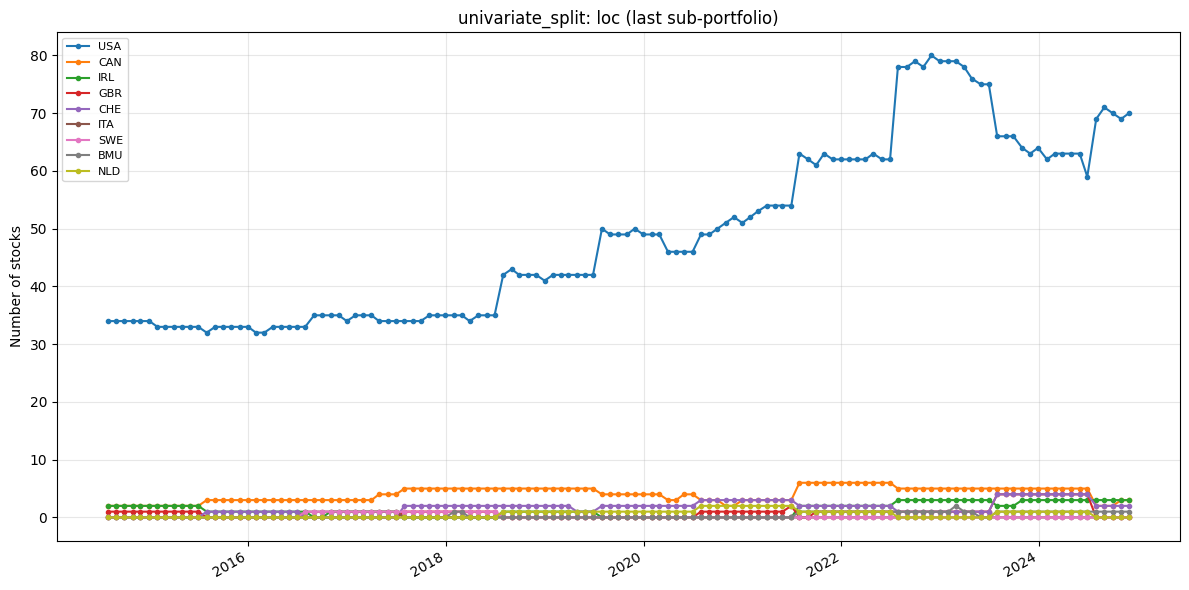

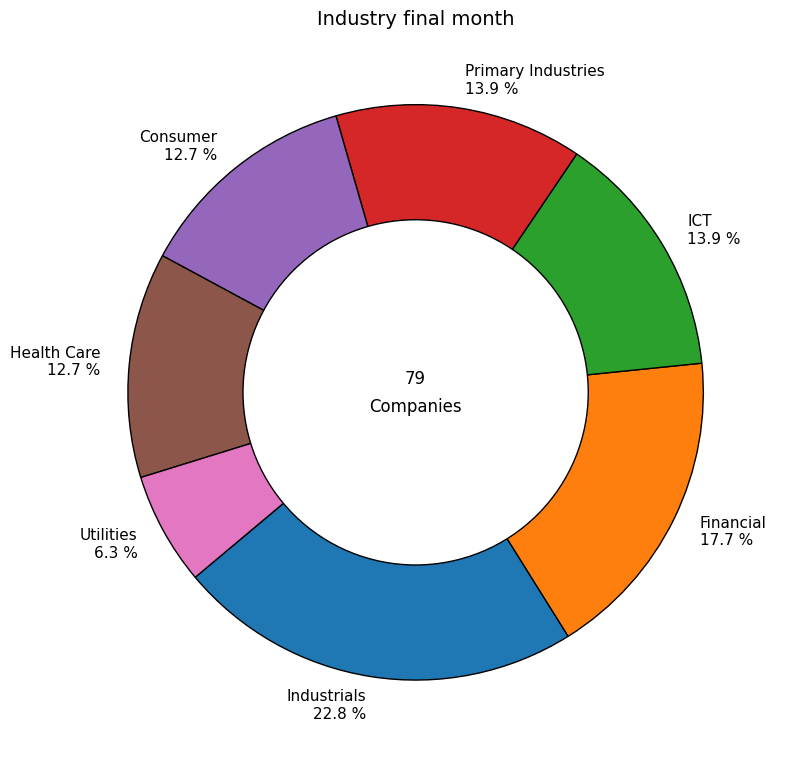

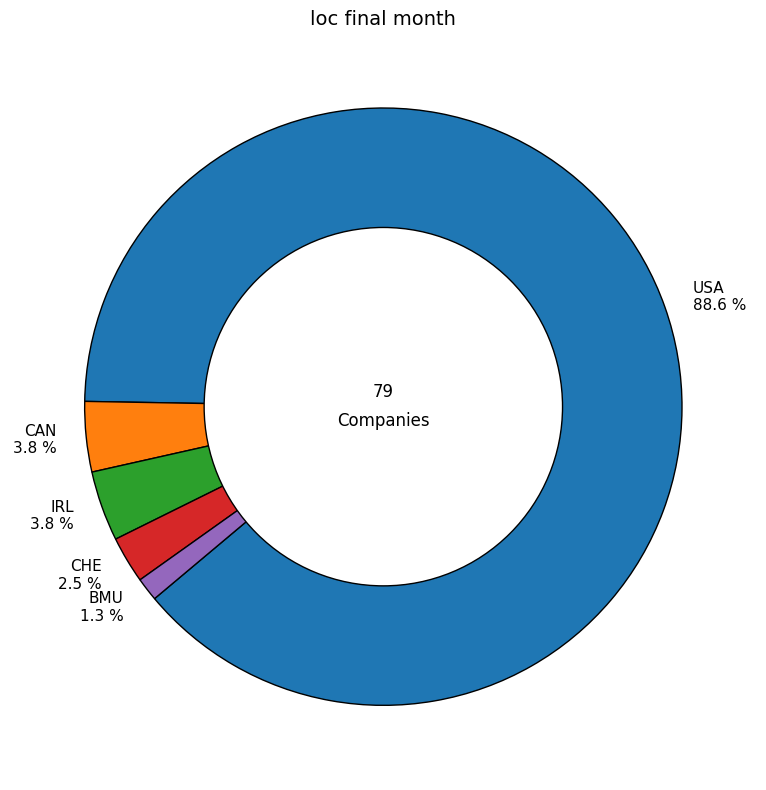

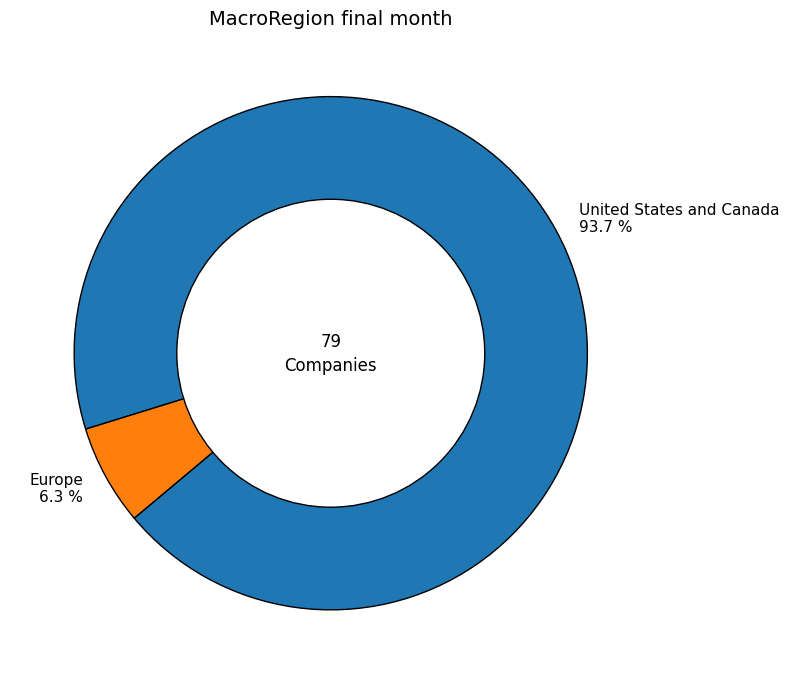

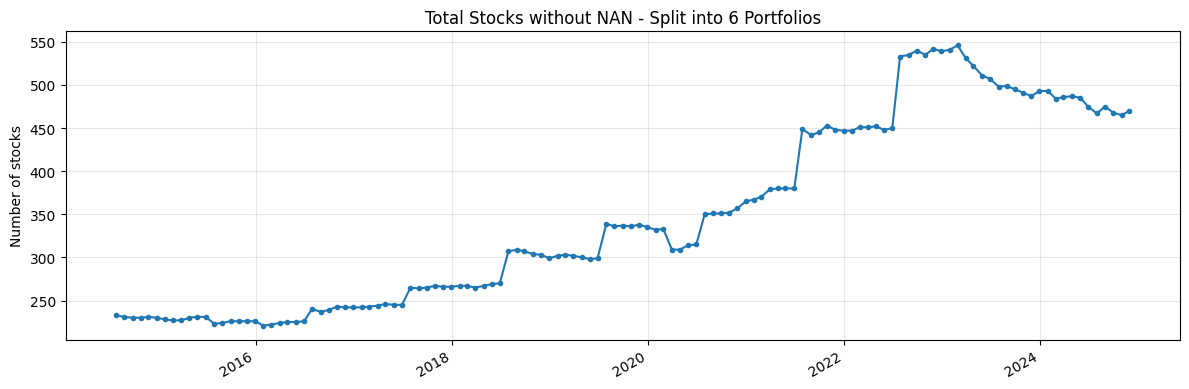

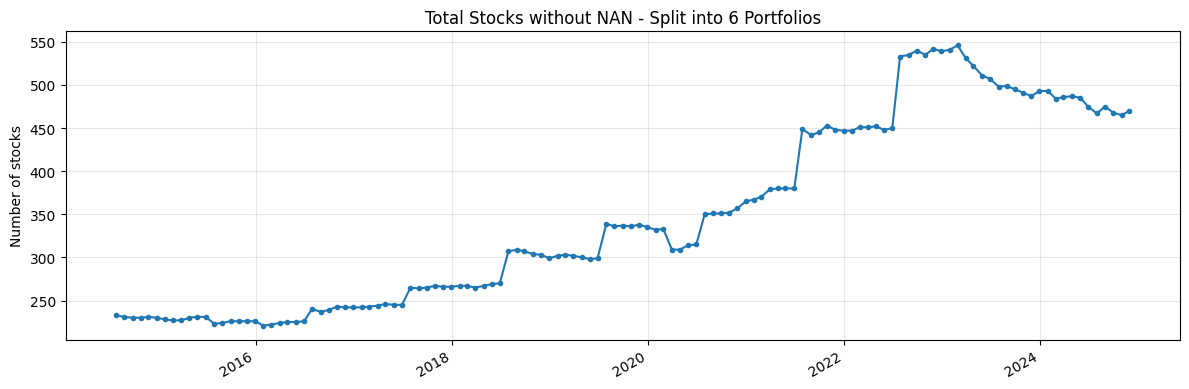

In [ ]:
from IPython.display import display
from functions.Portfolio_Constituents import PortfolioConstituents

# Portfolio constituents inspection is pinned to signal_2.
signal_2_simple_quantiles_constituents = signal_quantile_constituents["signal_2"]

pc2 = PortfolioConstituents(
    signal_2_simple_quantiles_constituents,
    global_universe,
    portfolio_type="univariate_split",
)




_dates, wide_industry = pc2._counts_by_category_over_time(
    "Industry",
    portfolio_key=None,  # ignored when analyse_all_portfolios_at_once=True
    analyse_all_portfolios_at_once=False,
)

pc2.run_all_plots(save=True, show=True)

# Options:
#pc2.run_all_plots(analyse_all_portfolios_at_once=True, save=True, show=True)
#pc2.run_all_plots(all_sub_portfolios=True, save=True, show=True)
# Plot (like your snippet)
pc2.total_stocks_over_time(title=f"Total Stocks without NAN - Split into {no_simple_quantiles} Portfolios")
